<div style="background:linear-gradient(135deg,#172554 0%,#1e40af 55%,#3b82f6 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#bfdbfe;font-weight:700;text-transform:uppercase">Chapter 136 &#183; Extended Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Case Study: Designing and Analyzing a Survey</div>
  <div style="font-size:15px;color:#dbeafe;max-width:740px;line-height:1.6">The Part 10 and Part 11 toolkit end to end: define the population, draw a stratified random sample, apply design weights, and estimate a proportion and a mean with honest margins of error, then size the next survey. The twist: the raw numbers say the parks levy fails, and correct weighting flips that verdict.</div>
  <div style="margin-top:16px;font-size:13px;color:#bfdbfe">Statistics, Data Science and AI: A Visual Handbook &#183; John Fisher &#183; 2026</div>
</div>

<div style="background:#eff6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1e40af;letter-spacing:1px">STEP 1 &#183; DEFINE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The decision, and the bar to clear</div>
<div style="color:#4a5578;margin-top:6px">A survey exists to answer a question a stakeholder will act on.</div>
</div>

The city parks board will put a small **parks levy** on the ballot only if a **majority of households support it**, and it wants a read on overall **satisfaction with the parks** (rated 1 to 5). So there are two population quantities to estimate: the **proportion** who support the levy (decision bar: is it above 50%?) and the **mean** satisfaction. A survey is only trustworthy if the sample represents the population and the estimate carries an honest margin of error, so both are the job here.

<div style="background:#eff6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1e40af;letter-spacing:1px">STEP 2 &#183; DESIGN</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Population, frame, and a stratified sample</div>
<div style="color:#4a5578;margin-top:6px">Who are we generalizing to, and how was the sample chosen?</div>
</div>

The **population** is 50,000 households across four **districts** (the strata), of unequal size and, as it turns out, unequal opinion. Instead of a simple random sample we use a **stratified random sample**: sample within each district so every district is represented, and deliberately **over-sample the small districts** so even the smallest has enough responses to report on. That design choice is exactly why the raw average will mislead unless we correct for it with **design weights**.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots
from statsmodels.stats.weightstats import DescrStatsW   # weighted mean/proportion + CIs (the R/SAS-style tool)
from statsmodels.stats.proportion import proportion_confint
EM="#2563eb"; DEEP="#1e40af"; LIGHT="#bfdbfe"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; GREEN="#059669"; AMBER="#d97706"; GREY="#94a3b8"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    df = pd.read_excel("../../data/case-study-designing-and-analyzing-a-survey--survey.xlsx", sheet_name="Data")
except FileNotFoundError: df = pd.read_excel(BASE+"case-study-designing-and-analyzing-a-survey--survey.xlsx", sheet_name="Data")
print("sampled households:", len(df))
df.head(4)

sampled households: 1200


,household_id,district,design_weight,responded,support_levy,satisfaction_1_5,age_band
0,1001,Riverside,83.3,1,0.0,5.0,18-34
1,1002,Riverside,83.3,1,1.0,3.0,55+
2,1003,Riverside,83.3,0,NaN,NaN,NaN
3,1004,Riverside,83.3,0,NaN,NaN,NaN


Each row is one **sampled household**. The `design_weight` is already in the file: it is the number of population households each respondent stands in for, computed as **stratum population divided by stratum sample size** (the inverse of the selection probability). A household in a lightly sampled big district represents many others; one in a heavily sampled small district represents few.

In [2]:
# The sampling design at a glance: population size, sample size, and the resulting design weight per district
design = (df.groupby("district")
            .agg(sampled=("household_id","size"), design_weight=("design_weight","first"))
            .assign(pop_est=lambda t: (t["sampled"]*t["design_weight"]).round().astype(int)))
print(design)
print(f"\nsample total = {design['sampled'].sum()}, population represented = {design['pop_est'].sum():,}")
print("note: Oldtown (small) was over-sampled, so its households carry the SMALLEST weight.")

           sampled  design_weight  pop_est
district                                  
Hillcrest      250           48.0    12000
Lakeside       250           16.0     4000
Oldtown        400           22.5     9000
Riverside      300           83.3    24990

sample total = 1200, population represented = 49,990
note: Oldtown (small) was over-sampled, so its households carry the SMALLEST weight.


<div style="background:#eff6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1e40af;letter-spacing:1px">STEP 3 &#183; COLLECT & INSPECT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Shape, response, and missingness</div>
<div style="color:#4a5578;margin-top:6px">Real surveys have nonrespondents; look before you leap.</div>
</div>

In [3]:
resp = df[df.responded==1]
print(f"mailed/contacted : {len(df)}")
print(f"responded        : {len(resp)}  ({len(resp)/len(df):.0%} response rate)")
print(f"nonrespondents   : {(df.responded==0).sum()}  (blank answers, excluded from estimates)")
print("\nmissing among respondents:", int(resp[['support_levy','satisfaction_1_5']].isna().sum().sum()))
print("response rate by district (roughly uniform here, so nonresponse is a minor issue):")
print((df.groupby('district').responded.mean().round(2)).to_string())

mailed/contacted : 1200
responded        : 932  (78% response rate)
nonrespondents   : 268  (blank answers, excluded from estimates)

missing among respondents: 0
response rate by district (roughly uniform here, so nonresponse is a minor issue):
district
Hillcrest    0.78
Lakeside     0.81
Oldtown      0.76
Riverside    0.77


About **78% responded**, and response is roughly uniform across districts, so **nonresponse bias is small** (we quantify it in the Take It Further notebook). The estimates below use the **respondents** only, each carried by its design weight.

<div style="background:#eff6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1e40af;letter-spacing:1px">STEP 4 &#183; EXPLORE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The picture, by district</div>
<div style="color:#4a5578;margin-top:6px">Always plot the groups before you average them.</div>
</div>

             n  support  satisfaction
district                             
Hillcrest  196    0.673         3.648
Lakeside   203    0.586         3.468
Oldtown    302    0.298         2.738
Riverside  231    0.736         3.944


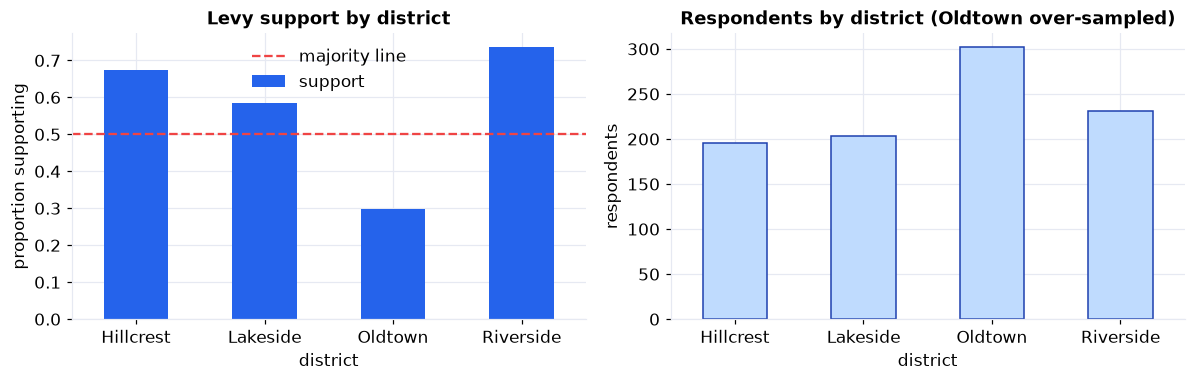

In [4]:
by_d = resp.groupby("district").agg(n=("support_levy","size"),
                                      support=("support_levy","mean"),
                                      satisfaction=("satisfaction_1_5","mean")).round(3)
print(by_d)
fig, ax = plt.subplots(1, 2, figsize=(11,3.6))
by_d["support"].plot(kind="bar", ax=ax[0], color=EM); ax[0].axhline(0.5, color=RED, ls="--", label="majority line")
ax[0].set(title="Levy support by district", ylabel="proportion supporting"); ax[0].legend(); ax[0].tick_params(axis='x', rotation=0)
by_d["n"].plot(kind="bar", ax=ax[1], color=LIGHT, edgecolor=DEEP)
ax[1].set(title="Respondents by district (Oldtown over-sampled)", ylabel="respondents"); ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

Two things jump out. **Support varies a lot by district** (Oldtown around 0.34, Riverside around 0.71), and **Oldtown is the largest bar of respondents** even though it is a small district, because we over-sampled it. That mismatch, big sample share but small population share, is precisely what biases a naive average.

<div style="background:#eff6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1e40af;letter-spacing:1px">STEP 5 &#183; THE TRAP</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The naive average is biased</div>
<div style="color:#4a5578;margin-top:6px">Averaging the raw responses secretly weights by who you sampled, not who lives there.</div>
</div>

In [5]:
naive_p = resp.support_levy.mean()
lo, hi = proportion_confint(int(resp.support_levy.sum()), len(resp), alpha=0.05, method="wilson")
print(f"NAIVE (unweighted) support = {naive_p:.3f}  ->  {naive_p:.0%}   95% CI [{lo:.3f}, {hi:.3f}]")
print(f"naive mean satisfaction    = {resp.satisfaction_1_5.mean():.3f}")
print("\nThe raw sample is 33% Oldtown households, but Oldtown is only 18% of the city.")
print("Over-representing a low-support district drags the unweighted average DOWN.")

NAIVE (unweighted) support = 0.548  ->  55%   95% CI [0.516, 0.580]
naive mean satisfaction    = 3.387

The raw sample is 33% Oldtown households, but Oldtown is only 18% of the city.
Over-representing a low-support district drags the unweighted average DOWN.


Taken at face value the survey says **support is about 55%... but the interval sits close to the majority line and the point estimate has been pulled down** by the over-sampled, low-support district. Reporting this number would understate real support. The fix is not more data, it is the right **weights**.

<div style="background:#eff6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1e40af;letter-spacing:1px">STEP 6 &#183; WEIGHT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Design weights fix the composition</div>
<div style="color:#4a5578;margin-top:6px">Weight each respondent back to the population it represents.</div>
</div>

In [6]:
# statsmodels DescrStatsW does weighted estimation directly: give it the 0/1 support and the design weights.
ws = DescrStatsW(resp.support_levy.values, weights=resp.design_weight.values)
w_p = ws.mean
print(f"DESIGN-WEIGHTED support = {w_p:.3f}  ->  {w_p:.0%}")
print(f"naive was               = {naive_p:.3f}  ->  {naive_p:.0%}")
print(f"true population value    = 0.621  (we happen to know it for this teaching dataset)")
print("\nWeighting each respondent by stratum-pop / stratum-sample rebuilds the real city mix,")
print("and the estimate jumps from a minority to a clear MAJORITY.")

DESIGN-WEIGHTED support = 0.631  ->  63%
naive was               = 0.548  ->  55%
true population value    = 0.621  (we happen to know it for this teaching dataset)

Weighting each respondent by stratum-pop / stratum-sample rebuilds the real city mix,
and the estimate jumps from a minority to a clear MAJORITY.


**The headline flips.** Weighting lifts support from about **55% to 63%**, from below the majority line to comfortably above it, and lands right on the true 62% (which we know only because this is a simulated population). Same respondents, same answers; the only change is counting each one by how many real households it stands for. This is the single most important habit in survey analysis: **estimate on weights, not raw counts.**

<div style="background:#eff6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1e40af;letter-spacing:1px">STEP 7 &#183; UNCERTAINTY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A margin of error you can defend</div>
<div style="color:#4a5578;margin-top:6px">A point estimate without an interval is an opinion.</div>
</div>

weighted support = 0.631  95% CI [0.595, 0.668]   margin of error = +/- 3.7 pts
effective sample size (Kish) = 663 of 932 respondents   design effect = 1.41
-> unequal weights shrink the effective n from 932 to about 660, so the honest interval is wider.


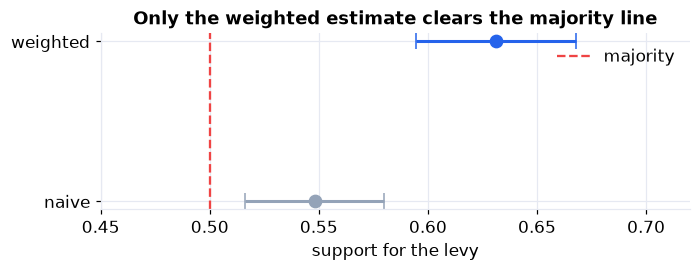

In [7]:
# Design weights are NOT frequency counts, so the plain weighted-variance CI would be far too tight.
# The honest interval uses a DESIGN-BASED standard error via the effective sample size (Kish).
w = resp.design_weight.values
n_eff = w.sum()**2 / (w**2).sum()        # Kish effective sample size
deff  = len(resp) / n_eff                # design effect: the precision cost of unequal weights
se    = np.sqrt(w_p*(1-w_p) / n_eff)
moe   = 1.96 * se
lo_w, hi_w = w_p - moe, w_p + moe
print(f"weighted support = {w_p:.3f}  95% CI [{lo_w:.3f}, {hi_w:.3f}]   margin of error = +/- {moe*100:.1f} pts")
print(f"effective sample size (Kish) = {n_eff:.0f} of {len(resp)} respondents   design effect = {deff:.2f}")
print("-> unequal weights shrink the effective n from 932 to about 660, so the honest interval is wider.")
fig, ax = plt.subplots(figsize=(6.5,2.6))
for i,(lab,p_,l,h,c) in enumerate([("naive",naive_p,lo,hi,GREY),("design-weighted",w_p,lo_w,hi_w,EM)]):
    ax.errorbar(p_, i, xerr=[[p_-l],[h-p_]], fmt="o", color=c, capsize=5, lw=2, ms=8)
ax.axvline(0.5, color=RED, ls="--", label="majority"); ax.set_yticks([0,1]); ax.set_yticklabels(["naive","weighted"])
ax.set(xlim=(0.45,0.72), title="Only the weighted estimate clears the majority line", xlabel="support for the levy"); ax.legend()
plt.tight_layout(); plt.show()

The weighted estimate is **63% with a margin of error of about plus or minus 4 points** (roughly 59% to 67%), and the whole interval sits above 50%: the levy has majority support, and we can say so with 95% confidence. Notice the **design effect** of about 1.4: because the weights are unequal, the effective sample size drops from 932 to about 660, so the honest interval is wider than the textbook formula would give. Ignoring that would overstate our precision.

<div style="background:#eff6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1e40af;letter-spacing:1px">STEP 8 &#183; THE MEAN</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The weighted mean, with its interval</div>
<div style="color:#4a5578;margin-top:6px">The same weighting logic applies to averages, not just proportions.</div>
</div>

In [8]:
wm = DescrStatsW(resp.satisfaction_1_5.values, weights=resp.design_weight.values)
se_m = wm.std / np.sqrt(n_eff)          # design-based SE: weighted SD over the effective n from Step 7
lo_s, hi_s = wm.mean - 1.96*se_m, wm.mean + 1.96*se_m
print(f"weighted mean satisfaction = {wm.mean:.2f} (1-5 scale)   95% CI [{lo_s:.2f}, {hi_s:.2f}]")
print(f"naive mean was             = {resp.satisfaction_1_5.mean():.2f}  (biased low, same reason as support)")
print(f"true population mean        = 3.63")

weighted mean satisfaction = 3.62 (1-5 scale)   95% CI [3.54, 3.70]
naive mean was             = 3.39  (biased low, same reason as support)
true population mean        = 3.63


Satisfaction tells the same story: the naive average understates it at about **3.39**, while the design-weighted mean is **3.62** (true value 3.63), with a tight 95% interval. `DescrStatsW` did the weighted mean and its confidence interval in one call, the library-first way to avoid hand-rolling weighted-variance formulas.

<div style="background:#eff6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1e40af;letter-spacing:1px">STEP 9 &#183; SAMPLE SIZE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">How big should the next survey be?</div>
<div style="color:#4a5578;margin-top:6px">Design the next study to hit a target precision.</div>
</div>

In [9]:
# For a target margin of error on a proportion: n = (z/MoE)^2 * p(1-p), inflated by the design effect.
z = 1.96; p = w_p
for target in [0.05, 0.03, 0.02]:
    n_srs = (z/target)**2 * p*(1-p)
    n_design = n_srs * deff
    print(f"target +/-{target*100:>2.0f} pts  ->  {n_srs:5.0f} respondents (simple random)  |  {n_design:5.0f} with this design effect ({deff:.2f})")
print("\nUse p=0.5 for the most conservative (largest) n when you have no prior estimate.")

target +/- 5 pts  ->    358 respondents (simple random)  |    503 with this design effect (1.41)
target +/- 3 pts  ->    994 respondents (simple random)  |   1397 with this design effect (1.41)
target +/- 2 pts  ->   2236 respondents (simple random)  |   3144 with this design effect (1.41)

Use p=0.5 for the most conservative (largest) n when you have no prior estimate.


To pin support down to **plus or minus 3 points** you need roughly **1,000 respondents** under simple random sampling, and more once the design effect is folded in. Planning this **before** collecting data is the difference between a survey that can answer the question and one that comes back inconclusive.

<div style="background:#eff6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1e40af;letter-spacing:1px">STEP 10 &#183; INTERPRET</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">What the numbers actually say</div>
<div style="color:#4a5578;margin-top:6px">Translate the estimates into the decision.</div>
</div>

Putting it together: an estimated **63% of households (95% CI about 59% to 67%) support the parks levy**, a clear majority, and mean satisfaction is **3.6 out of 5**. The raw, unweighted survey would have reported support *below* a majority and satisfaction lower than it truly is, and the board might have shelved a popular measure. The correction was not fancy modeling; it was **weighting each respondent back to the population**, the core idea of Parts 10 and 11.

<div style="background:#eff6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1e40af;letter-spacing:1px">STEP 11 &#183; CAVEATS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">What could still bias this</div>
<div style="color:#4a5578;margin-top:6px">Honesty about the limits is part of the report.</div>
</div>

Three honest caveats. **Nonresponse:** about 22% did not answer; response here is roughly uniform across districts so the bias is small, but a real survey should check whether respondents differ from nonrespondents on what matters (the Take It Further notebook runs that sensitivity analysis and a post-stratification adjustment). **Coverage:** the frame is households on the city register; anyone off the register cannot be sampled. **Measurement:** a single satisfaction item is a coarse instrument. None of these overturns the majority finding, but a good analyst names them rather than hiding them.

<div style="background:#eff6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1e40af;letter-spacing:1px">STEP 12 &#183; COMMUNICATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">One paragraph for the parks board</div>
<div style="color:#4a5578;margin-top:6px">Plain English, decision-ready.</div>
</div>

**For the board:** A stratified survey of 1,200 households (about 930 responding) estimates that **63% of city households support the parks levy** (95% margin of error about plus or minus 4 points), a clear majority, and that satisfaction with the parks averages **3.6 out of 5**. An important note on method: the raw responses appear to show only minority support, but that is an artifact of deliberately over-sampling one small, less-supportive district; after weighting each response back to the true population, support is a solid majority. We recommend proceeding, and sizing any confirmatory survey at roughly 1,000 completed responses to hold the margin of error near plus or minus 3 points.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook &#183; &#169; 2026 John Fisher</div>